# 02 · Scenarios S0–S5

Runs every preset, reports when the cash gap closes, and applies the FY2047-48 and 2070 tests. Preset values are design choices except where `NOTES` names a source.

In [1]:
import sys; sys.path.insert(0, '..')
import pandas as pd
from discom_sim import *
base = base_from_table(read_csv('baseline_all_india_fy2021.csv'))
import matplotlib.pyplot as plt

In [2]:
rows = []
for name, lv in PRESETS.items():
    res = simulate(base, lv)
    rows.append({'scenario': name, 'gap closes (FY ending)': first_gap_close_year(res),
                 'passes FY2047-48 test': profitable_test(res)['passed'], 'passes 2070 test': viksit_test(res)['passed'],
                 'gap 2030 (Rs/kWh)': round(res.loc[2030,'gap_per_kwh'],2),
                 'hike needed (solver)': solve_tariff_hike(base, lv)})
pd.DataFrame(rows).set_index('scenario')

,gap closes (FY ending),passes FY2047-48 test,passes 2070 test,gap 2030 (Rs/kWh),hike needed (solver)
scenario,,,,,
S0 Business as usual,NaN,False,False,3.00,0.046753
S1 Announced policies,NaN,False,False,1.47,0.042505
S2 Profitable by FY2047-48,2028.0,True,True,-0.02,0.038696
S3 Viksit Bharat DISCOMs by 2070,2028.0,True,True,-0.49,0.023389
S5 Stress,NaN,False,False,5.69,0.059644


Text(0.5, 1.0, 'Cash gap to FY2047-48 by scenario')

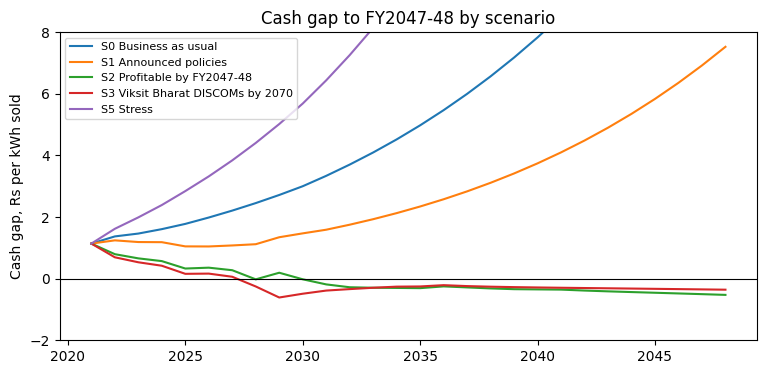

In [3]:
fig, ax = plt.subplots(figsize=(9,4))
for name, lv in PRESETS.items():
    res = simulate(base, lv)
    ax.plot(res.loc[:2048].index, res.loc[:2048,'gap_per_kwh'], label=name)
ax.axhline(0, color='k', lw=0.8); ax.set_ylabel('Cash gap, Rs per kWh sold'); ax.set_ylim(-2, 8); ax.legend(fontsize=8)
ax.set_title('Cash gap to FY2047-48 by scenario')

### Components of the gap in the target scenario

In [4]:
res = simulate(base, PRESETS['S2 Profitable by FY2047-48'])
(res.loc[[2021,2025,2030,2035,2040,2048],['D','C','S','RI','residual','cash_gap']] / 1e5).round(2).rename(columns=lambda c: c + ' (lakh cr)')

,D (lakh cr),C (lakh cr),S (lakh cr),RI (lakh cr),residual (lakh cr),cash_gap (lakh cr)
fy,,,,,,
2021,0.18,0.22,0.20,0.07,0.36,1.04
2025,0.18,0.24,0.13,0.00,-0.18,0.37
2030,0.14,0.14,0.00,0.00,-0.31,-0.03
2035,0.00,0.08,0.00,0.00,-0.64,-0.56
2040,0.00,0.13,0.00,0.00,-0.93,-0.80
2048,0.00,0.26,0.00,0.00,-2.06,-1.79


### Preset notes and sources

In [5]:
pd.Series(NOTES)

tariff_hike                    BAU 1.9% = median approved hike FY26 (I1); S2 ...
trueup_lag                                      About two years in practice (C1)
appc_escalation                             4.7%/yr = APPC growth FY07-FY21 (C1)
ri_share_end                   S1 onward: no new regulatory assets, existing ...
billing_loss_end                                 S2: single-digit AT&C goal (P2)
collection_loss_end            S2: 0.5% allowed collection loss used in tarif...
cost_reflective_after_close    S2/S3: after the gap closes, tariffs follow co...
other                          All other preset values are design choices (DE...
dtype: str